# PAGA

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
OBJ = "airway-epithelium"
OBJ_V = 'reclustered'
OBJ_PATH= MAIN_DIR / 'data' / 'sub' / OBJ / 'h5ad' / f'{OBJ}-{OBJ_V}.h5ad'

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
obj = sc.read_h5ad(OBJ_PATH)

### Whole object

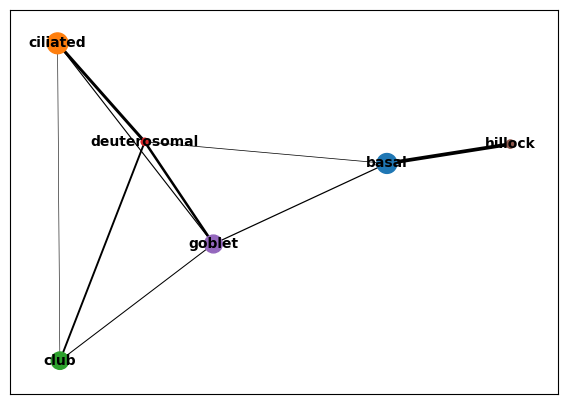

In [5]:
LABELS_KEY = 'reclustered_ct'

sc.tl.paga(
    obj, 
    groups=LABELS_KEY
)

sc.pl.paga(
    obj, 
    threshold=0.05,
)

### CF

In [17]:
cf_obj = obj[obj.obs['condition']=='CF'].copy()
cf_obj

AnnData object with n_obs × n_vars = 175007 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'leiden', 'reclustered_ct'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_3_colors', 'dendrogram_leiden', 'donor_colors', 'hvg', 'leiden', 'leiden_col

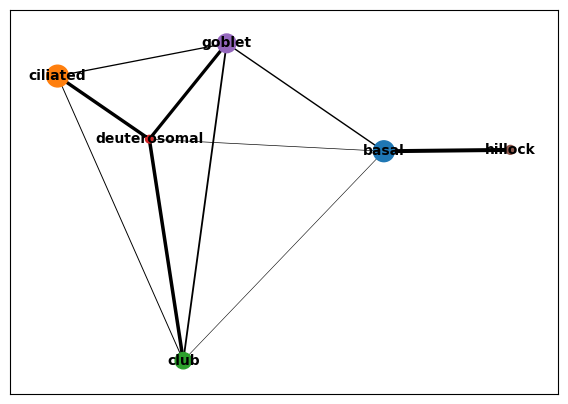

In [18]:
# Recompute neighbours using the representation used in your analysis
rsc.pp.neighbors(
    cf_obj,
    n_neighbors=15,
    use_rep="X_resolvi"  # replace with X_pca, X_resolVI, etc.
)

LABELS_KEY = 'reclustered_ct'

sc.tl.paga(
    cf_obj, 
    groups=LABELS_KEY
)

sc.pl.paga(
    cf_obj, 
    threshold=0.05,
)

In [10]:
cf_obj.obs[LABELS_KEY].value_counts()

reclustered_ct
ciliated        63643
basal           53895
goblet          34572
club            20175
hillock          1777
deuterosomal      945
Name: count, dtype: int64

### CTRL

In [13]:
ctrl_obj = obj[obj.obs['condition']=='CTRL'].copy()
ctrl_obj

AnnData object with n_obs × n_vars = 25941 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'leiden', 'reclustered_ct'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_3_colors', 'dendrogram_leiden', 'donor_colors', 'hvg', 'leiden', 'leiden_colo

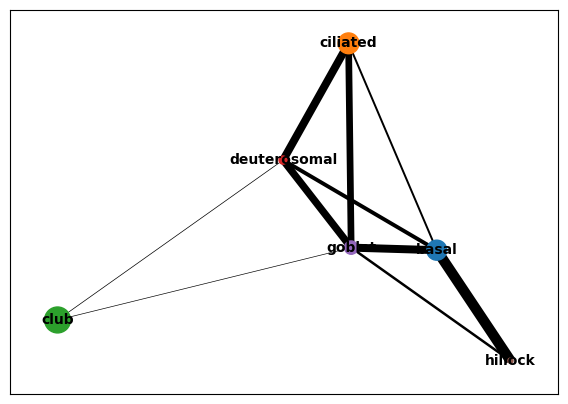

In [16]:
# Recompute neighbours using the representation used in your analysis
rsc.pp.neighbors(
    ctrl_obj,
    n_neighbors=15,
    use_rep="X_resolvi"  # replace with X_pca, X_resolVI, etc.
)

sc.tl.paga(
    ctrl_obj,
    groups=LABELS_KEY
)

sc.pl.paga(
    ctrl_obj,
    threshold=0.05
)

In [8]:
ctrl_obj.obs[LABELS_KEY].value_counts()

reclustered_ct
club            14034
ciliated         5772
basal            4996
goblet            979
deuterosomal      138
hillock            22
Name: count, dtype: int64

In [ ]:
sc.pl.paga_compare(ctrl_obj, basis="umap")